In [19]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## ShallowLearn Specific imports

In [20]:
from ShallowLearn.api_download import get_credentials
import ShallowLearn.QuickLook as qck_lk
import ShallowLearn.ExtractMetadata as parse_metadata
import ShallowLearn.Util as util
import ShallowLearn.API_Utils as api_utils

## Standard imports

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

from datetime import date
from shapely.geometry import box
import os
import requests

## cdsetool Specific imports

In [22]:
from cdsetool.query import query_features, shape_to_wkt
from cdsetool.credentials import Credentials
from cdsetool.download import download_features
from cdsetool.monitor import StatusMonitor
from cdsetool.query import describe_collection

In [23]:
search_terms = describe_collection("Sentinel2").keys()

## Helper function to generate features from bbox 

In [24]:
features = api_utils.generate_query("55LCD")

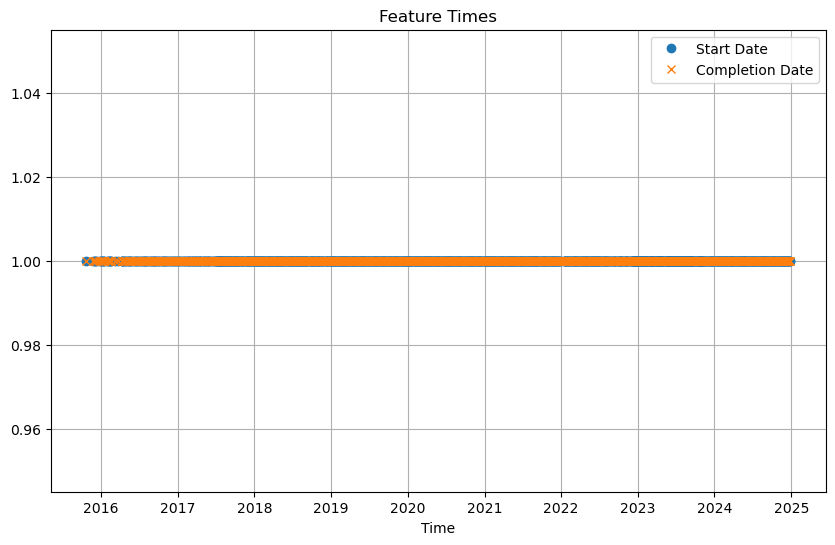

,id,startDate,completionDate,cloudCover,processingBaseline,title
0,35e8ca60-9f18-4898-9587-8ddb2892ad41,2024-07-26 00:27:11.024000+00:00,2024-07-26 00:27:11.024000+00:00,99.865150,5.11,S2A_MSIL1C_20240726T002711_N0511_R016_T55LCD_2...
1,b9461255-1b87-4cd5-bb9b-d1282ddd12ad,2024-08-28 00:37:01.024000+00:00,2024-08-28 00:37:01.024000+00:00,37.791275,5.11,S2A_MSIL1C_20240828T003701_N0511_R059_T55LCD_2...
2,33f52b7f-ec60-4dfa-ac27-55fc0d45b43c,2024-08-20 00:27:09.024000+00:00,2024-08-20 00:27:09.024000+00:00,24.972216,5.11,S2B_MSIL1C_20240820T002709_N0511_R016_T55LCD_2...
3,25ee9d8e-1d5c-4810-b8fb-9085093a4344,2024-08-10 00:27:09.024000+00:00,2024-08-10 00:27:09.024000+00:00,16.731056,5.11,S2B_MSIL1C_20240810T002709_N0511_R016_T55LCD_2...
4,3a0e754d-0d12-415f-b76a-fae904f6f049,2024-09-12 00:37:09.024000+00:00,2024-09-12 00:37:09.024000+00:00,32.167607,5.11,S2B_MSIL1C_20240912T003709_N0511_R059_T55LCD_2...
...,...,...,...,...,...,...
1285,575d0af5-d3de-5953-8c5d-e4b6b669d00c,2021-12-24 00:26:59.024000+00:00,2021-12-24 00:26:59.024000+00:00,73.688390,5.00,S2B_MSIL1C_20211224T002659_N0500_R016_T55LCD_2...
1286,c626c7c0-389b-591b-9ccd-dd70f3abaaf9,2021-12-07 00:36:59.024000+00:00,2021-12-07 00:36:59.024000+00:00,36.925378,5.00,S2B_MSIL1C_20211207T003659_N0500_R059_T55LCD_2...
1287,c7cee624-fbf5-5139-8d19-05a87dbc123c,2021-12-04 00:27:09.024000+00:00,2021-12-04 00:27:09.024000+00:00,99.992957,5.00,S2B_MSIL1C_20211204T002709_N0500_R016_T55LCD_2...
1288,d1bf8e58-41d9-5025-a34c-d461925f2b2b,2021-11-29 00:27:11.024000+00:00,2021-11-29 00:27:11.024000+00:00,29.771994,5.00,S2A_MSIL1C_20211129T002711_N0500_R016_T55LCD_2...


In [25]:
api_utils.plot_sentinel_features(features)

In [26]:
thumbnail_dir = "/mnt/sda_mount/Additional_Experiments/thumbnails/"

In [28]:
pvi_api = qck_lk.QuickLookAPIPVI(features, thumbnail_dir, download_thumbnails=False)


Error processing /mnt/sda_mount/Additional_Experiments/thumbnails/S2A_MSIL1C_20240726T002711_N0511_R016_T55LCD_20240726T033656.SAFE.jpg: [Errno 2] No such file or directory: '/mnt/sda_mount/Additional_Experiments/thumbnails/S2A_MSIL1C_20240726T002711_N0511_R016_T55LCD_20240726T033656.SAFE.jpg'
Error processing /mnt/sda_mount/Additional_Experiments/thumbnails/S2B_MSIL1C_20240820T002709_N0511_R016_T55LCD_20240820T013439.SAFE.jpg: [Errno 2] No such file or directory: '/mnt/sda_mount/Additional_Experiments/thumbnails/S2B_MSIL1C_20240820T002709_N0511_R016_T55LCD_20240820T013439.SAFE.jpg'
Error processing /mnt/sda_mount/Additional_Experiments/thumbnails/S2B_MSIL1C_20240810T002709_N0511_R016_T55LCD_20240810T012922.SAFE.jpg: [Errno 2] No such file or directory: '/mnt/sda_mount/Additional_Experiments/thumbnails/S2B_MSIL1C_20240810T002709_N0511_R016_T55LCD_20240810T012922.SAFE.jpg'
Error processing /mnt/sda_mount/Additional_Experiments/thumbnails/S2B_MSIL1C_20240731T002709_N0511_R016_T55LCD_2024

/home/zba21/Documents/ShallowLearn/ShallowLearn/QuickLook.py:410: RuntimeWarning: Mean of empty slice.
  mean_1 = np.array(self.imagery)[self.column_updated_df.Label == 1].mean()
/home/zba21/.local/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [29]:
class_dict = pvi_api.class_dict


#### Class dict is a dictionary estimate based on where we would expect the imagery to plot (based on expected PC space / cluster locations)

In [44]:
class_dict

{-1: ('#1f77b4', 'Partially Cloudy'),
 2: ('#d62728', 'No Data'),
 0: ('#ff7f0e', 'Clear Sky'),
 1: ('#2ca02c', 'Opaque Clouds')}

### Tune eps/samples to optimize number of images

In [42]:
pvi_api.predict(pvi_api.transformed_data, eps = 100, min_samples=10);

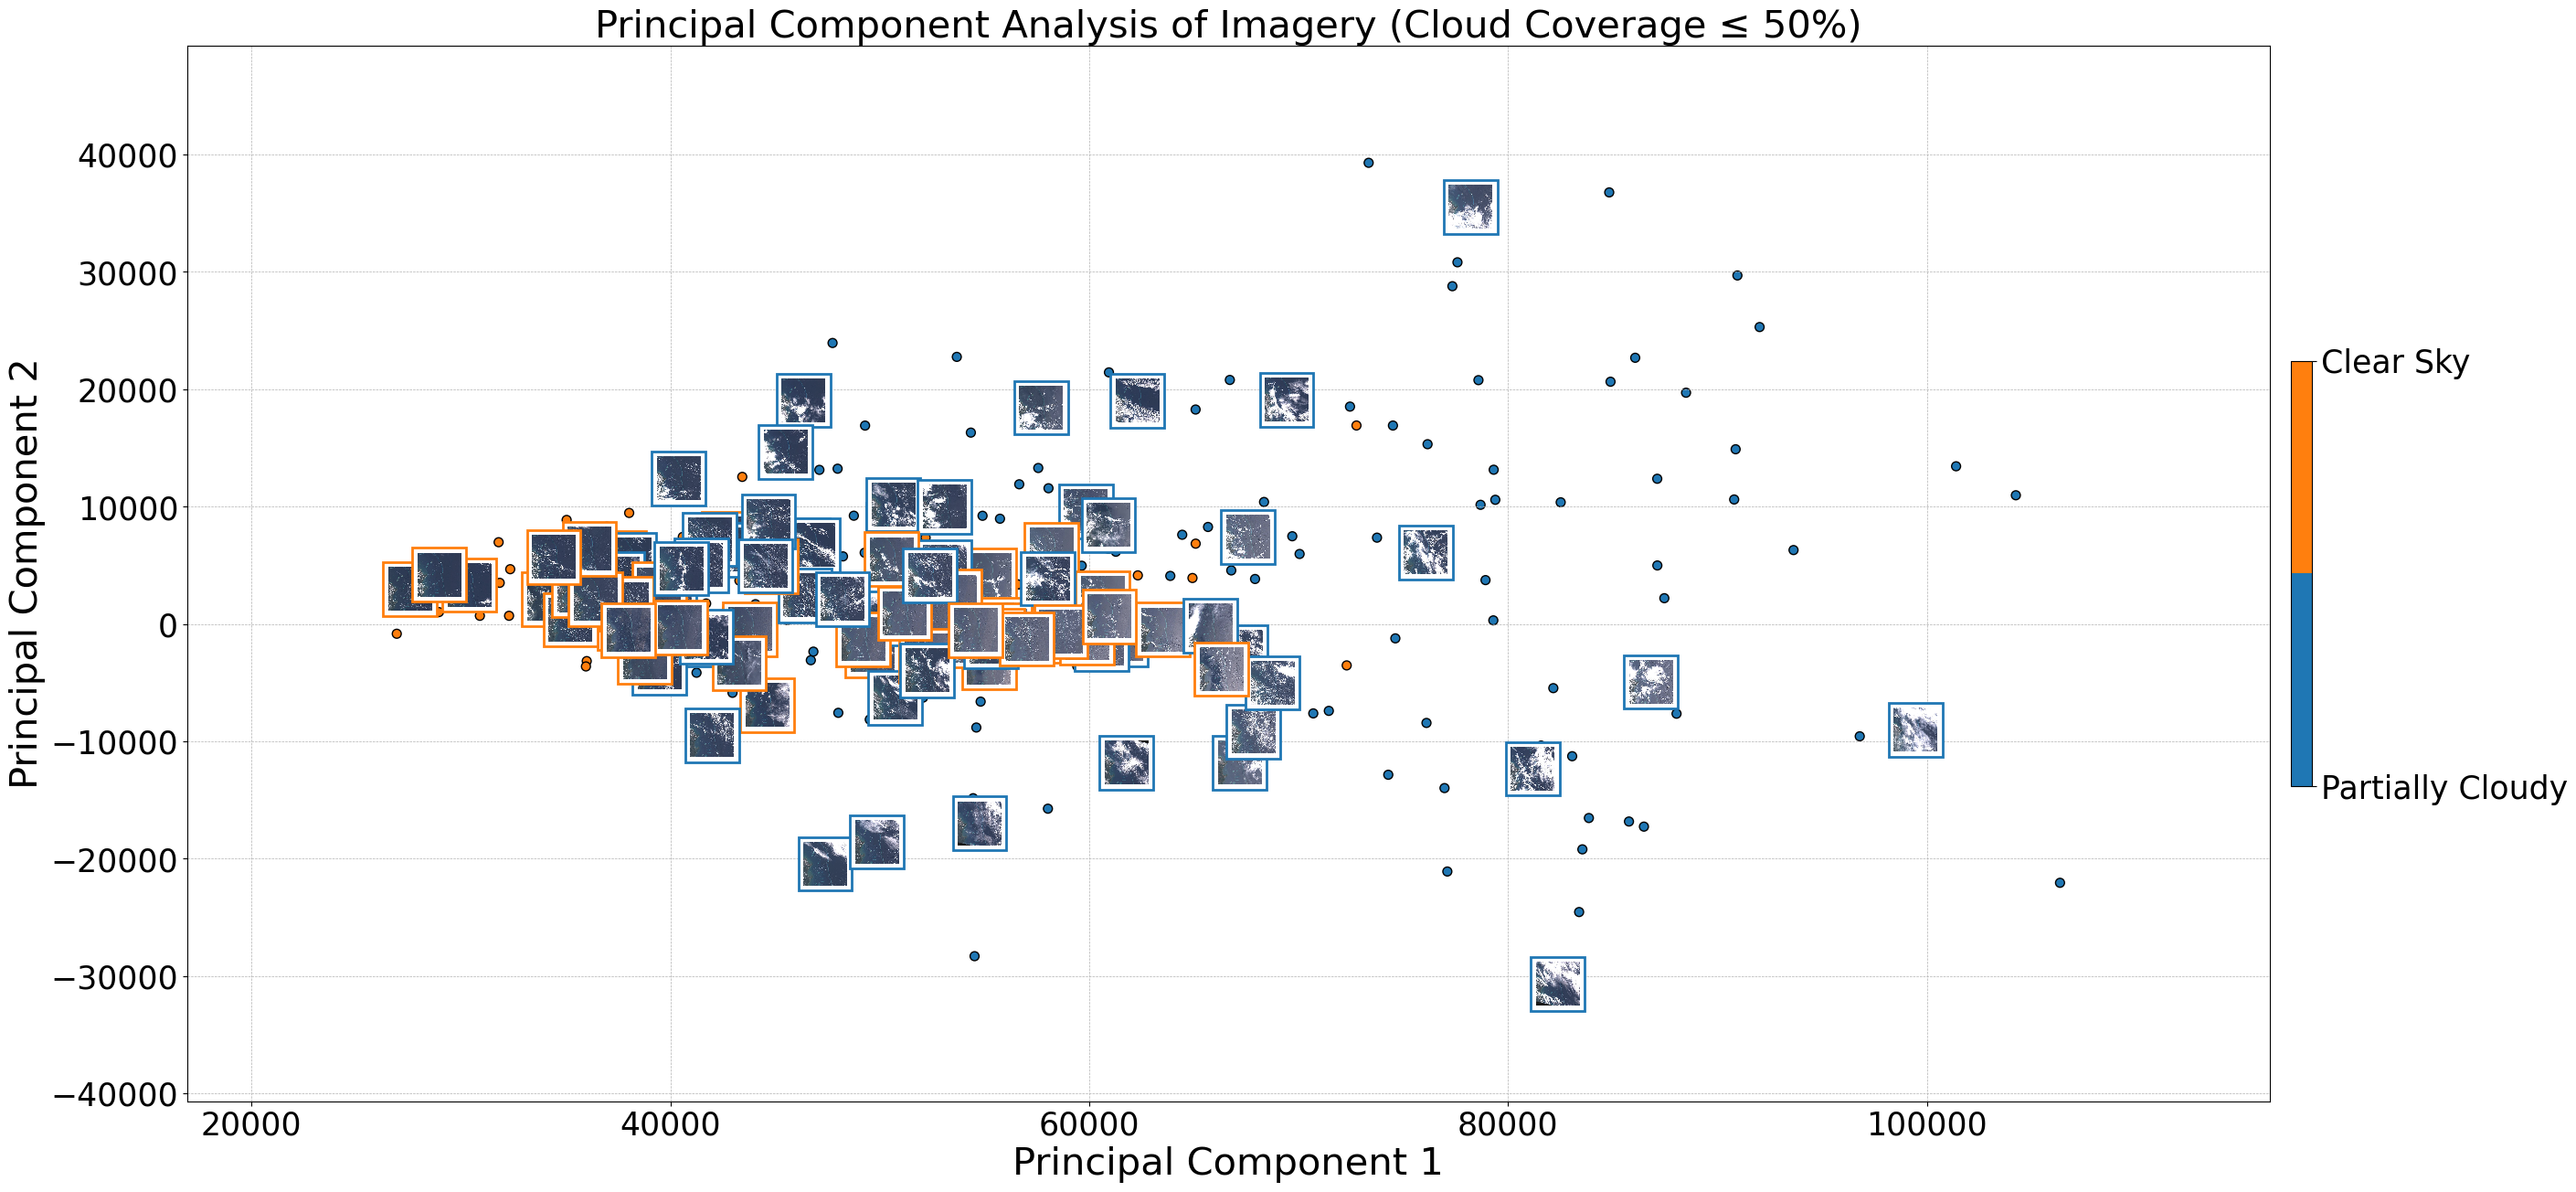

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (30, 15))
pvi_api.plot_principal_components(pvi_api.column_updated_df, zoom = 0.1, cloud_threshold = 50,class_dict=class_dict, ax = ax , plot_meshgrid = False)

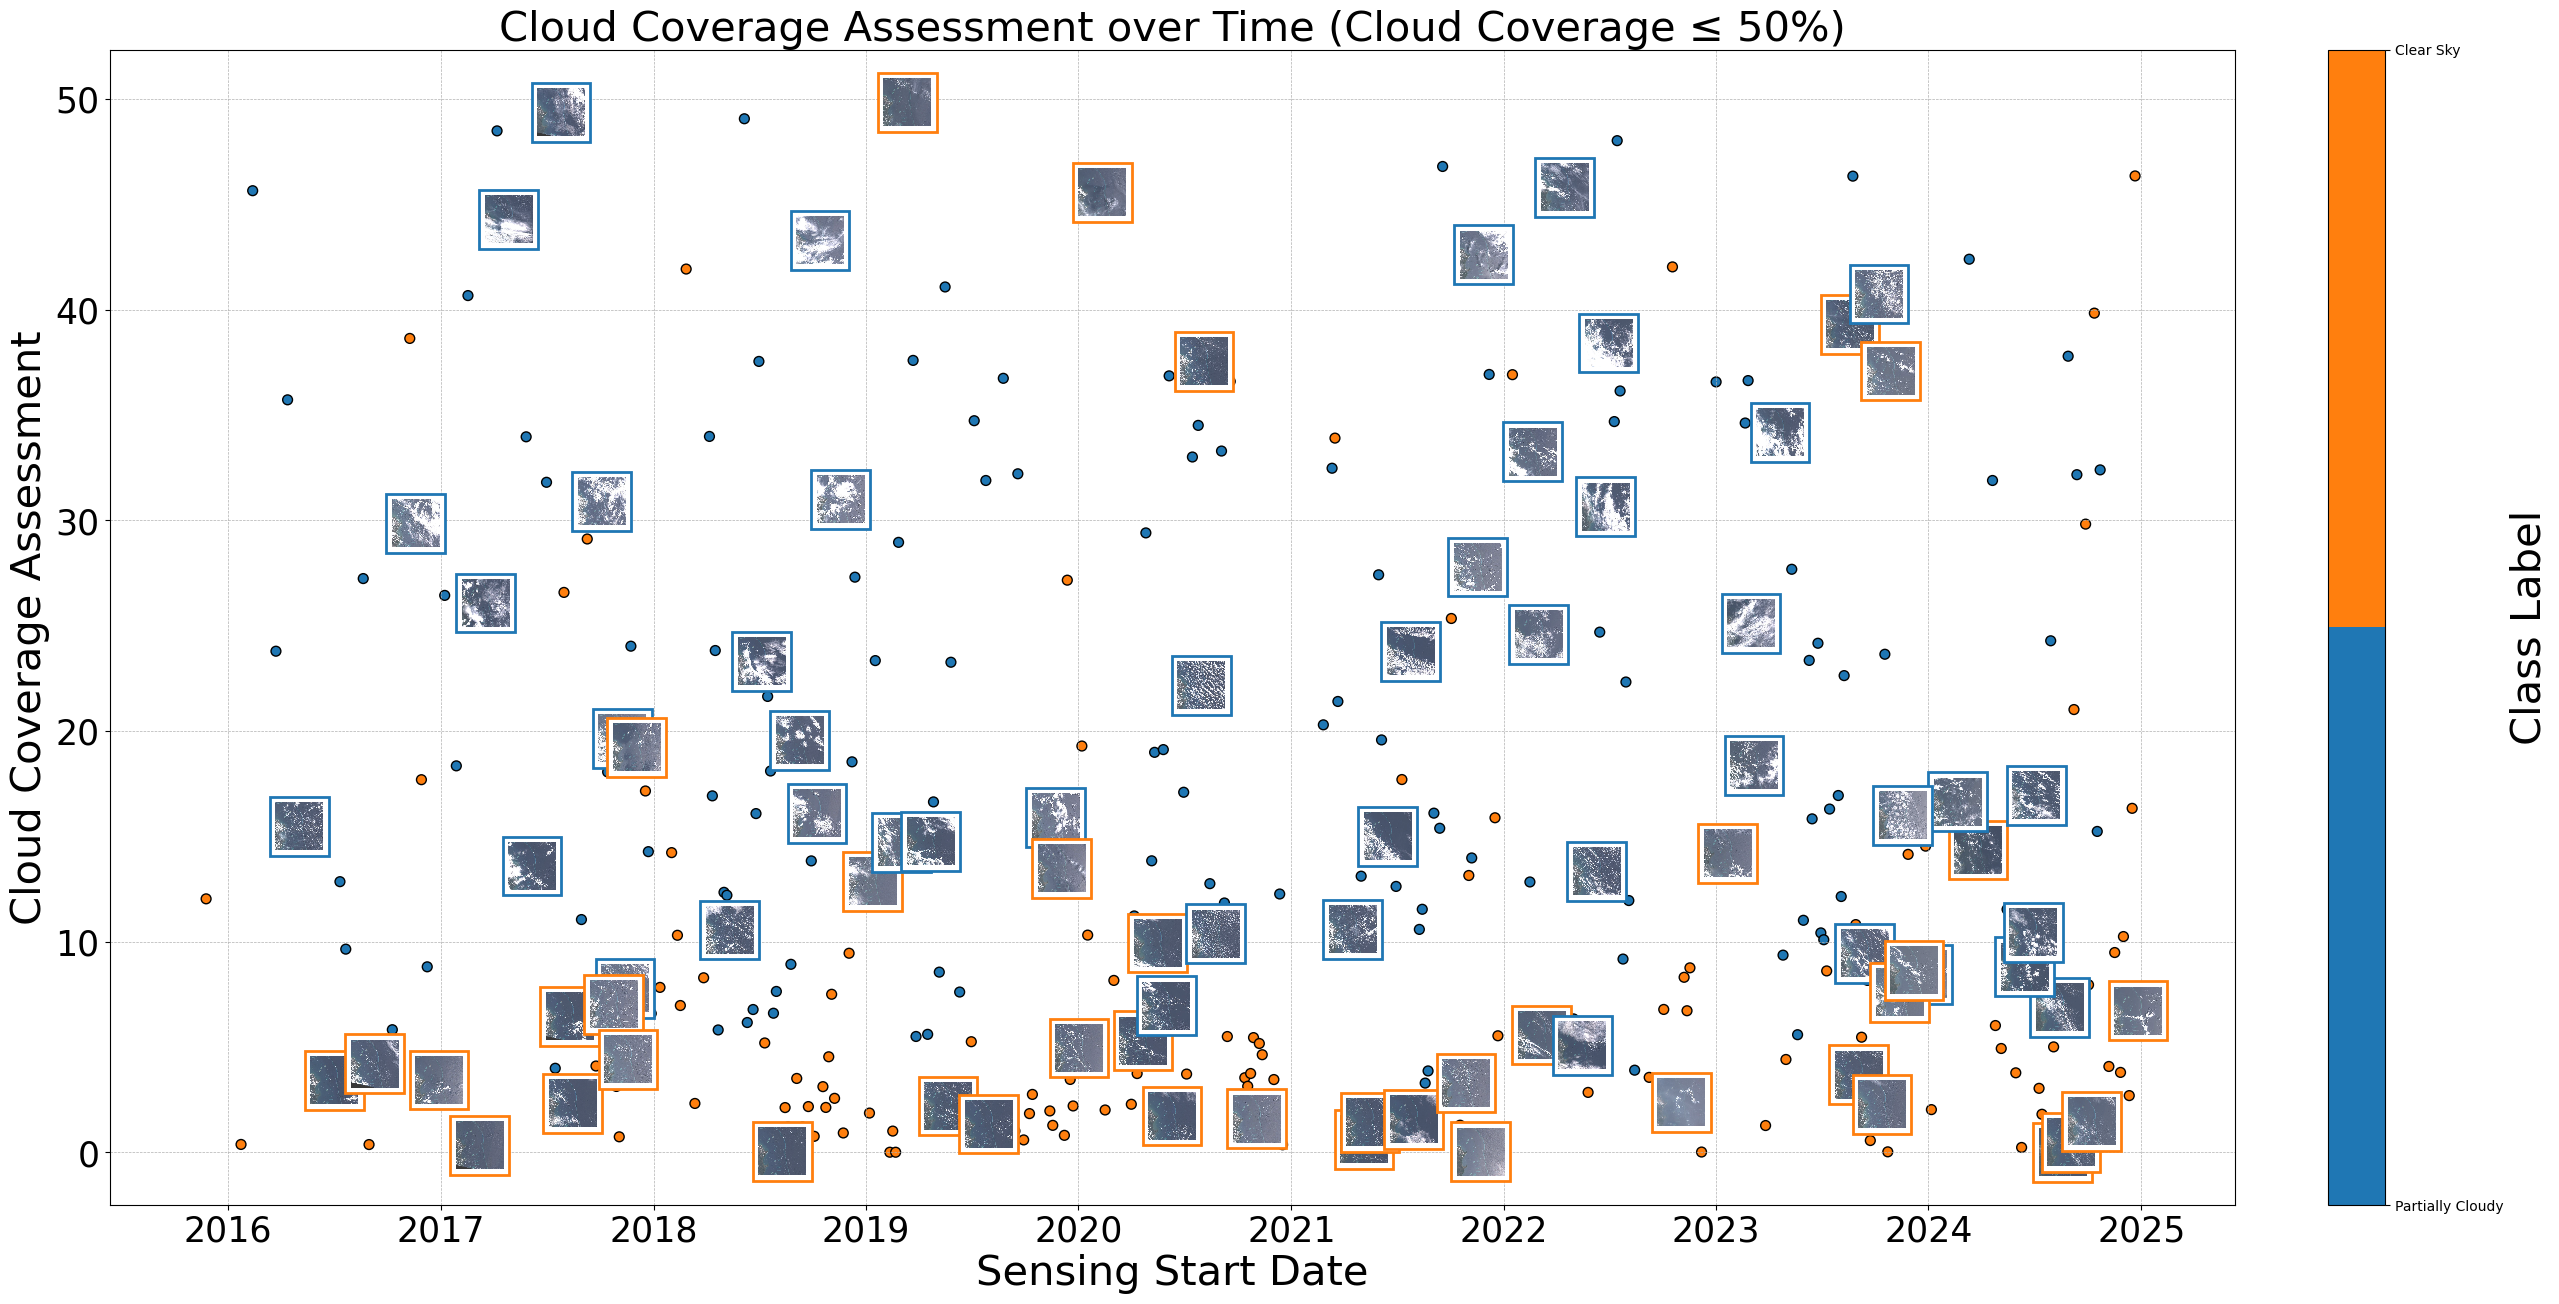

In [46]:
fig, ax = plt.subplots(1,1, figsize = (30, 15))
pvi_api.plot_cloud_coverage(pvi_api.column_updated_df, zoom = 0.1, cloud_threshold = 50,class_dict = class_dict, ax = ax)

### Finally return the query in the format needed for the ESA API

In [48]:
pvi_api.get_cloud_free_dataset()

[{'type': 'Feature',
  'id': 'f332faab-e79b-4a5f-a6c4-a3cf2953fff1',
  'geometry': {'type': 'Polygon',
   'coordinates': [[[145.1444838043406, -14.464971661637737],
     [145.13592807348905, -15.457175756439401],
     [146.15917630599273, -15.463421573787747],
     [146.1630376798323, -14.47079905042279],
     [145.1444838043406, -14.464971661637737]]]},
  'properties': {'collection': 'SENTINEL-2',
   'status': 'ONLINE',
   'license': {'licenseId': 'unlicensed',
    'hasToBeSigned': 'never',
    'grantedCountries': None,
    'grantedOrganizationCountries': None,
    'grantedFlags': None,
    'viewService': 'public',
    'signatureQuota': -1,
    'description': {'shortName': 'No license'}},
   'parentIdentifier': None,
   'title': 'S2A_MSIL1C_20240818T003701_N0511_R059_T55LCD_20240818T013535.SAFE',
   'description': 'The Copernicus Sentinel-2 mission consists of two polar-orbiting satellites that are positioned in the same sun-synchronous orbit, with a phase difference of 180°. It aims 

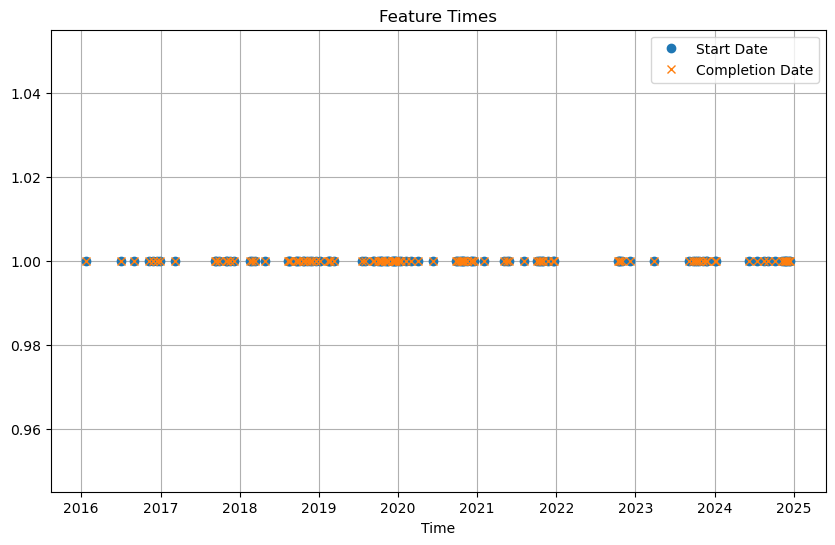

,id,startDate,completionDate,cloudCover,processingBaseline,title
0,f332faab-e79b-4a5f-a6c4-a3cf2953fff1,2024-08-18 00:37:01.024000+00:00,2024-08-18 00:37:01.024000+00:00,0.008421,5.11,S2A_MSIL1C_20240818T003701_N0511_R059_T55LCD_2...
1,92ead0e9-9d0d-44a1-bc15-7431b05651fa,2024-09-02 00:37:09.024000+00:00,2024-09-02 00:37:09.024000+00:00,0.478396,5.11,S2B_MSIL1C_20240902T003709_N0511_R059_T55LCD_2...
2,c2b2b547-985e-479a-b153-01ce8e9872de,2024-10-07 00:37:01.024000+00:00,2024-10-07 00:37:01.024000+00:00,1.465765,5.11,S2A_MSIL1C_20241007T003701_N0511_R059_T55LCD_2...
3,ebff5550-3bca-420a-9a87-00790639aca2,2024-11-06 00:37:01.024000+00:00,2024-11-06 00:37:01.024000+00:00,4.078085,5.11,S2A_MSIL1C_20241106T003701_N0511_R059_T55LCD_2...
4,bdeb19b0-7f2e-4be6-b17d-491be5743fd3,2024-11-16 00:37:01.024000+00:00,2024-11-16 00:37:01.024000+00:00,9.486189,5.11,S2A_MSIL1C_20241116T003701_N0511_R059_T55LCD_2...
...,...,...,...,...,...,...
105,303b8f40-6062-4de9-b641-76688acb2e13,2021-10-13 00:37:11.025000+00:00,2021-10-13 00:37:11.025000+00:00,0.811550,5.00,S2A_MSIL1C_20211013T003711_N0500_R059_T55LCD_2...
106,37ae12ab-d181-4f2b-a013-970f47c331fe,2021-11-02 00:37:11.024000+00:00,2021-11-02 00:37:11.024000+00:00,13.143510,5.00,S2A_MSIL1C_20211102T003711_N0500_R059_T55LCD_2...
107,702352a0-cdce-5782-9e67-571a339e6a8b,2021-10-28 00:37:09.024000+00:00,2021-10-28 00:37:09.024000+00:00,3.289438,5.00,S2B_MSIL1C_20211028T003709_N0500_R059_T55LCD_2...
108,9fb85954-a7ed-5a47-bb0d-f6430580d72b,2021-10-18 00:37:09.024000+00:00,2021-10-18 00:37:09.024000+00:00,1.290334,5.00,S2B_MSIL1C_20211018T003709_N0500_R059_T55LCD_2...


In [49]:
api_utils.plot_sentinel_features(pvi_api.get_cloud_free_dataset())

## Helper function with environment variables containing ESA user/pass combo

In [50]:
creds = get_credentials()

#### Now just download the data normally to some path

In [ ]:
save_path = "Some_Directory"

In [ ]:

list(
    download_features(
        features,
        save_path,
        {
            "concurrency": 4,
            "monitor": StatusMonitor(),
            "credentials": Credentials(creds['sentinel_username'], creds['sentinel_password']),
            
        },
    )
)